In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')

import pymc as pm
from main_pool import Main
from calibr_funcs import plot_results

from networks.model_output import SEIRModelOutput, SEIRParams
from networks.SEIR_network import SEIRNetworkModel

from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data

#pip install -e git+https://github.com/Mpkosh/Mathematics-of-Epidemics-on-Networks.git@my_changes#egg=eon

import plot_funcs
import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
%load_ext autoreload
%autoreload 2

pm.__version__  #'5.24.0'

'5.25.1'

In [ ]:
import numpy as np
import pymc as pm

In [2]:
# True parameter values
alpha, sigma = 1, 1
beta = [1, 2.5]

RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

# Size of dataset
size = 100

# Predictor variable
X1 = np.random.randn(size)
X2 = np.random.randn(size) * 0.2

# Simulate outcome variable
Y = alpha + beta[0] * X1 + beta[1] * X2 + rng.normal(size=size) * sigma

basic_model = pm.Model()

with basic_model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = alpha + beta[0] * X1 + beta[1] * X2

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)
    idata = pm.sample(tune=2, draws=2, chains=1)

Only 2 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [alpha, beta, sigma]


Sampling 1 chain for 2 tune and 2 draw iterations (2 + 2 draws total) took 0 seconds.
The number of samples is too small to check convergence reliably.


## stuff

In [17]:
# generate synthetic data with known parameters for testing
true_tau = 0.1
true_alpha = 0.95
init_inf = 0.0001
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)
data_p = 'new_network_check/'
'''
observed_data = generate_synthetic_data(alpha=true_alpha, lmbd=true_lmbd, 
                                        days=days, data_path=data_p,
                                       with_seirb=True, with_switch=False,
                                       for_observed=True)
'''

'''
self.G = nx.barabasi_albert_graph(population=10**5, 5)
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate
init_inf_frac = 1e-4 # fraction of initially infected

alpha = 0.95
beta = 0.1
'''


'\nself.G = nx.barabasi_albert_graph(population=10**5, 5)\ngamma = 0.3 # latent period rate\ndelta = 0.2 # recovery rate\ninit_inf_frac = 1e-4 # fraction of initially infected\n\nalpha = 0.95\nbeta = 0.1\n'

In [18]:
pot = glob.glob('../new_sw_100000/'+
            f'p_{true_tau}_{gamma}_{delta}_{init_inf}_{true_alpha}*')

pot

['../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_0.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_1.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_2.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_3.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_4.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_5.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_6.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_7.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_8.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.9500000000000006_seed_9.csv']

In [46]:
path = '../new_sw_100000\\p_0.5799999999999997_0.3_0.2_0.0001_0.8000000000000005_seed_0.csv'
seed_df = pd.read_csv(path, usecols=['E','S'])
# calculating incidence
temp = seed_df[['E','S']].shift([0,1])
seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                    (temp['S_0'] - temp['S_1'])
seed_df['incidence'].fillna(0, inplace=True)
seed_df

,S,E,incidence
0,79991,0,0.0
1,79990,1,0.0
2,79988,3,0.0
3,79987,2,2.0
4,79981,4,4.0
...,...,...,...
145,4069,160,54.0
146,4044,139,46.0
147,4014,125,44.0
148,3993,113,33.0


In [49]:
#seed_df[['incidence']].to_csv('incidence_sw.csv', 
                             index=False)


In [128]:
q = glob.glob('../new_sw_100000/*.csv')[::10]
import random
random.seed(42)
random.sample(q,10)

['../new_sw_100000\\p_0.7499999999999997_0.3_0.2_0.0001_0.5800000000000003_seed_0.csv',
 '../new_sw_100000\\p_0.20999999999999996_0.3_0.2_0.0001_0.5200000000000002_seed_0.csv',
 '../new_sw_100000\\p_0.13999999999999999_0.3_0.2_0.0001_0.6400000000000003_seed_0.csv',
 '../new_sw_100000\\p_0.8499999999999996_0.3_0.2_0.0001_0.9400000000000006_seed_0.csv',
 '../new_sw_100000\\p_0.3799999999999999_0.3_0.2_0.0001_0.3300000000000001_seed_0.csv',
 '../new_sw_100000\\p_0.34999999999999987_0.3_0.2_0.0001_0.2700000000000001_seed_0.csv',
 '../new_sw_100000\\p_0.3199999999999999_0.3_0.2_0.0001_0.8800000000000006_seed_0.csv',
 '../new_sw_100000\\p_0.23999999999999994_0.3_0.2_0.0001_0.4300000000000002_seed_0.csv',
 '../new_sw_100000\\p_0.8499999999999996_0.3_0.2_0.0001_0.5300000000000002_seed_0.csv',
 '../new_sw_100000\\p_0.1_0.3_0.2_0.0001_0.5900000000000003_seed_0.csv']

## work

In [3]:
'''
'../new_sw_100000\\p_0.5799999999999997_0.3_
0.2_0.0001_0.8000000000000005_seed_0.csv'
'''

true_tau = 0.58
true_alpha = 0.8
init_inf = 0.0001
gamma = 0.3 # latent period rate
delta = 0.2 # recovery rate

days=range(1, 150)

<Axes: >

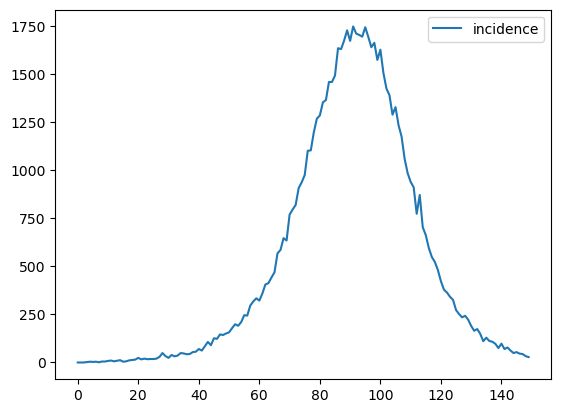

In [4]:
observed_data = pd.read_csv('incidence_sw.csv')
observed_data.plot()

In [6]:
# create
network_params = {'n_nodes': 100000,
                  'network_type': 'sw'}
#observed_prv = observed_data[['incidence']]
hn = NetworkSEIR_tuned(observed_data, network_params,
                       fixed_sigma=gamma, fixed_gamma=delta)

'''
true_tau = 0.58
true_alpha = 0.8
'''
# define parameter ranges for priors
prior_ranges = {"tau": (0.57, 0.59),  
                "alpha": (0.79, 0.81) 
                }

start_time = time.time()
# run History Matching
hm_results = hn.history_matching(prior_ranges, 
                                 n_samples=1000,
                                 adaptive=True, 
                                 accept_ratio=.1,
                                 prepared=True, folder='../hybrid_surrogate/sim_data/new_sw_100000/')
end_time = time.time()

print('It took: ', end_time - start_time)

Network SEIR - Fixed parameters: sigma = 0.3, gamma = 0.2
Calibrating parameters
Running Network SEIR history matching with 1000 samples...


Network History Matching: 100%|████████████| 1000/1000 [04:24<00:00,  3.78it/s]

Accepted 100 parameter sets
It took:  265.0212399959564


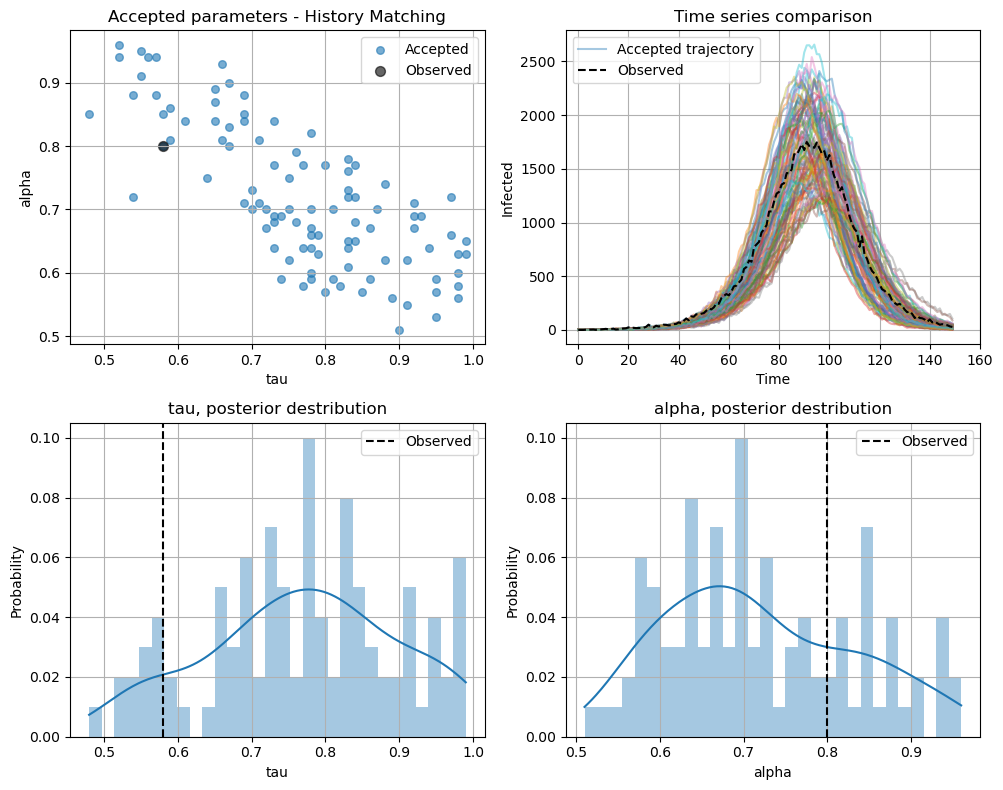

In [7]:
plot_results(observed_data, hm_results, 
             "History Matching", n_trajectories=len(hm_results),
             true_p0=true_tau, true_p1=true_alpha)

In [8]:
hm_results['tau'].quantile(.1), hm_results['tau'].quantile(.9)

(np.float64(0.5789999999999997), np.float64(0.9499999999999995))

In [9]:
hm_results['alpha'].quantile(.1), hm_results['alpha'].quantile(.9)

(np.float64(0.5800000000000003), np.float64(0.8800000000000006))

In [10]:
def switch_seir(sim_data, gamma=0.1, delta=0.08,
                frac=0.01, modeling_duration=249, 
                method='expanding'):
    
    pop = sim_data.iloc[0,:4].sum()
    '''
    switches = sim_data[sim_data['I'] > pop*frac]
    
    if switches.shape[0]:
        switch_day = switches.index[0]
    else:
        switch_day = 7
    '''
    
    switch_day = sim_data.shape[0]-1
    y0 = sim_data.iloc[switch_day,:4].values.flatten()
    # FOR FULL OBSERVED DATA
    ts = np.arange(modeling_duration-switch_day)
    if method=='expanding':
        beta = sim_data.iloc[:switch_day]['Beta'
                                ].expanding(1).mean().values[-1]
    elif method=='last':
        beta = sim_data.iloc[:switch_day]['Beta'].values[-1]
    elif method=='rolling':
        beta = sim_data.iloc[:switch_day]['Beta'
                                ].rolling(7).mean().values[-1]

    # Median from HM accepted parameters' trajectories!
    #median_b = pd.read_csv('median_beta.csv')
    #beta = median_b.iloc[switch_day:].values
    S,E,I,R = seir_discrete.seir_model(y0, ts, beta, 
                                       gamma, delta, stype='d', 
                                       beta_t=False).T

    fin = pd.DataFrame([S,E,I,R]).T
    fin.columns = ['S','E','I','R']

    fin['Beta'] = beta
    fin['day'] = ts+switch_day
    fin = pd.concat([sim_data.iloc[:switch_day], fin]
                   ).reset_index(drop=True)
    return fin

In [9]:
def simulation_func(rng, tau, alpha, modeling_duration, 
                    with_switch=False, num_runs=[1], 
                    frac=[0.01], size=None):
    
    tau = np.array(tau).flatten()[0]
    alpha = np.array(alpha).flatten()[0]
    
    modeling_duration = np.array(modeling_duration).flatten()[0]
    num_runs = np.array(num_runs).flatten()[0] 
    frac = np.array(frac).flatten()[0] 
    
    method='expanding'
    network_type='sw'    
    gamma = 0.3
    delta=0.2
    n_nodes=100000
    
    chosen_seed = np.random.RandomState(42)
    network_model = SEIRNetworkModel(n_nodes, network_type, 
                                     chosen_seed)
    init_inf_frac = 0.0001
    init_rec_frac = 1 - alpha

    all_results = []
    for run in range(np.array(num_runs).flatten()[0]):
        res = network_model.simulate(beta=tau, gamma=gamma, delta=delta, 
                                     init_inf_frac=init_inf_frac, 
                                     init_rec_frac=init_rec_frac,
                                     tmax=modeling_duration,
                                I_frac_switch=frac)

        seed_df = pd.DataFrame([res.S, res.E, res.I, res.R]).T
        seed_df.columns = ['S','E','I','R']
        seed_df['day'] = np.arange(seed_df.shape[0])
        # use "values", because "iloc" saves index info 
        # and messes with the calculation
        beta_calc = - seed_df.S.diff().values[1:] / (
                                seed_df.S.values[:-1] * seed_df.I.values[:-1]
                                )
        # the last Beta value cannot be calculated: no S_{t+1}
        seed_df['Beta'] = [*beta_calc, 0] 
        s = seed_df.shape[0]
        seed_df.fillna(0, inplace=True)
        if np.array(with_switch).flatten()[0]:
            if 'Beta' not in seed_df.columns:
                print(seed_df.columns)
            seed_df = switch_seir(seed_df, gamma=gamma, delta=delta,
                                  frac=np.array(frac).flatten()[0], 
                                  modeling_duration=modeling_duration, 
                                  method=method)

        # calculating incidence
        temp = seed_df[['E','S']].shift([0,1])
        seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                            (temp['S_0'] - temp['S_1'])
        #print(seed_df.iloc[s-5:s+2])
        seed_df['incidence'].fillna(0, inplace=True)
        all_results.append(seed_df)    

    if all_results:
        combined_results = pd.concat(all_results, 
                                     ignore_index=True)
        seed_df = combined_results.groupby('day').mean().reset_index()
        seed_df[['S','E','I','R',
                    'incidence']] = seed_df[['S','E','I','R',
                                             'incidence']].round()
    
    #print(seed_df['incidence'].astype(int))
    return seed_df['incidence'].astype(int).values
    

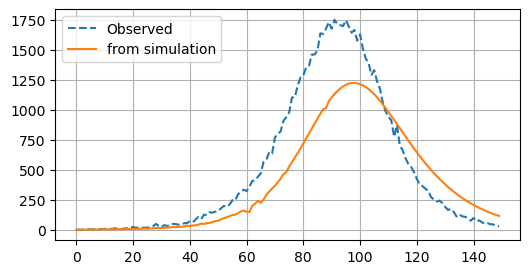

In [62]:
q = simulation_func(_, tau=[0.58], alpha=[0.8], 
                    modeling_duration=[150], 
                    with_switch=True, num_runs=[10], 
                    frac=[.01], size=None)

plt.subplots(figsize=(6,3))
plt.plot(observed_data.incidence, ls='--', label='Observed')
plt.plot(q, label='from simulation')

plt.grid()
plt.legend()

In [14]:
# 85 sec for 5x2, frac=0.01

draws = 100
chains = 2
progressbar = True

'''

'''

with_switch=np.array(True) 
num_runs=[1]
frac=[0.01]
gamma = 0.3
delta=0.2
n_nodes=100000


with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    p0_v = pm.Uniform(name="tau", 
                      lower=0.5789999999999997,#hm_results['tau'].quantile(.1), 
                      upper=np.float64(0.9499999999999995)#hm_results['tau'].quantile(.9)
                     )
    p1_v = pm.Uniform(name="alpha", 
                      lower=np.float64(0.5800000000000003), #hm_results['alpha'].quantile(.1), 
                      upper=np.float64(0.8800000000000006)#hm_results['alpha'].quantile(.9)
                     )
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #249
    

    sim = pm.Simulator("sim", simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac
                                 ),   
                       
                        epsilon=10, 
                        ndims_params=[1,1,1,1,1,1],
                        observed=observed_data['incidence'].values)
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))


# 10.5sec, 2x2, frac=0.001    
# 4472sec, 2x100, frac=0.01
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 2 chains in 2 jobs


We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [sim]


It took  4471.5654554367065 sec


In [15]:
idata

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\site-packages\IPython\extensions\autoreload.py", line 580, in superreload
    module = reload(module)
  File "C:\Users\MKoshkareva\anaconda3\envs\pymc_env\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.668,0.028,0.640,0.696,0.019,0.0,2.0,2.0,9.806858e+15
alpha,0.868,0.001,0.866,0.869,0.001,0.0,2.0,2.0,9.806858e+15


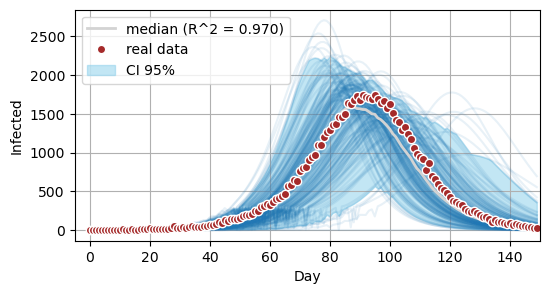

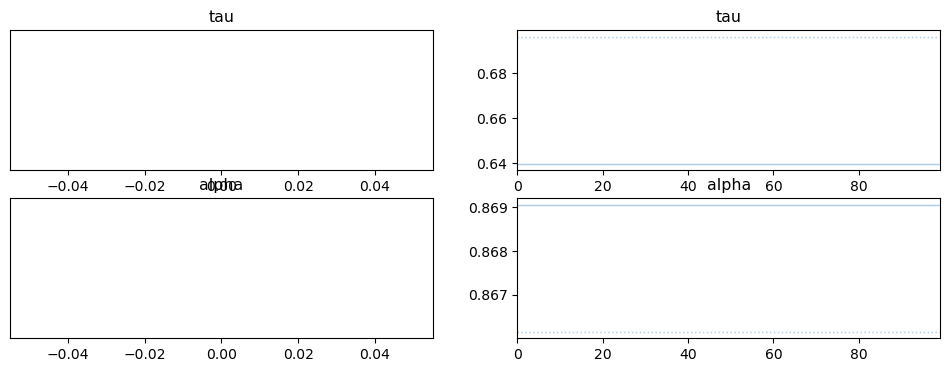

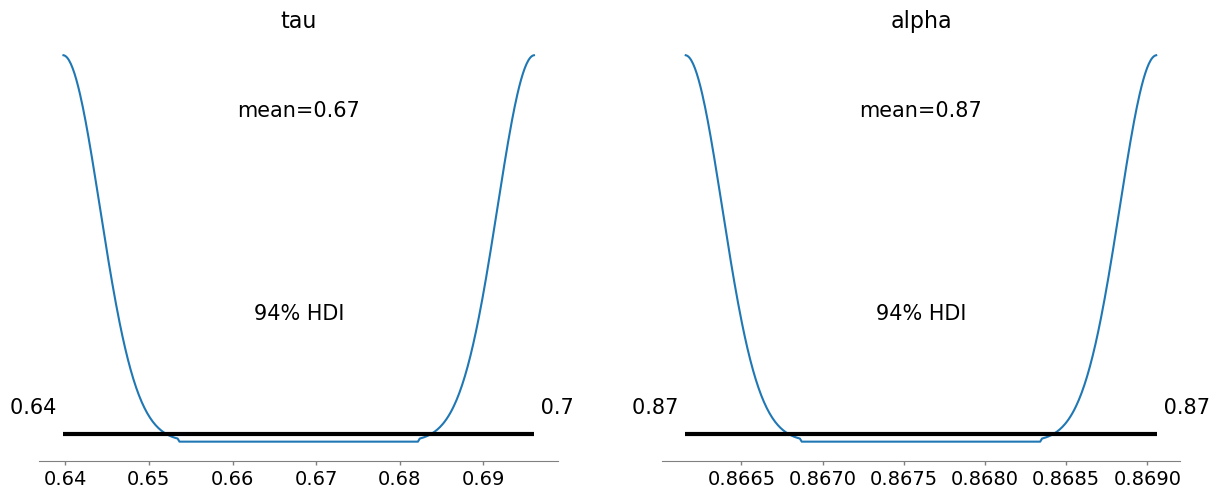

In [16]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)


In [ ]:
# 85 sec for 5x2, frac=0.01

draws = 5
chains = 2
progressbar = True

'''

'''

with_switch=np.array(True) 
num_runs=[1]
frac=[0.01]
gamma = 0.3
delta=0.2
n_nodes=100000


with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    p0_v = pm.Uniform(name="tau", 
                      lower=0.5789999999999997,#hm_results['tau'].quantile(.1), 
                      upper=np.float64(0.9499999999999995)#hm_results['tau'].quantile(.9)
                     )
    p1_v = pm.Uniform(name="alpha", 
                      lower=np.float64(0.5800000000000003), #hm_results['alpha'].quantile(.1), 
                      upper=np.float64(0.8800000000000006)#hm_results['alpha'].quantile(.9)
                     )
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #249
    

    sim = pm.Simulator("sim", simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac
                                 ),   
                       
                        epsilon=10000, 
                        ndims_params=[1,1,1,1,1,1],
                        observed=observed_data['incidence'].values)
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))


# 10.5sec, 2x2, frac=0.001    
# 4472sec, 2x100, frac=0.01
print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 2 chains in 2 jobs


In [ ]:
plot_funcs.plots(idata, observed_data['incidence'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)
